# AgriPulse — Food Price Forecasting

**Bei Smart / AgriPulse Capstone — Moringa School Data Science**

This notebook documents the development of the forecasting layer, from a first
single-series baseline through to the multi-model production pipeline.

It is written as a record of how the work actually unfolded. Several approaches
were tried and abandoned; those are kept in place because the reasons they failed
shaped the final design.

**Contents**

1. Setup and data
2. A first baseline — SARIMA on one series
3. Prophet as a comparison
4. Trying deep learning — 1D CNN
5. Scaling to many markets
6. Data quality problems found along the way
7. Adding external drivers — rainfall, fuel, geopolitical risk
8. Regional coverage
9. A second opinion — SARIMA at market level
10. Time-series foundation models — Chronos
11. Per-series model selection
12. Production pipeline and artifacts

## 1. Setup and data

The forecasting dataset combines WFP monthly market prices with two supplementary
sources added later in the project, plus ERA5 rainfall matched to each region and
month. Prices are normalised to KES per kilogram so that series recorded in
90 kg bags, 50 kg sacks and litres can be compared.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from prophet import Prophet
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import logging
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)
logging.getLogger('prophet').setLevel(logging.ERROR)

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_style('whitegrid')

In [2]:
DATA = r'C:\Users\matew\OneDrive\Documents\capstone\bei-smart\data\cleaned'

df = pd.read_csv(f'{DATA}\\bei_smart_forecasting.csv', parse_dates=['date'])

print(f"{len(df):,} rows | {df['date'].min():%b %Y} to {df['date'].max():%b %Y}")
print(f"{df['commodity'].nunique()} commodities across {df['market'].nunique()} markets")

26,228 rows | Jan 2006 to Aug 2026
47 commodities across 225 markets


### Choosing a starting series

Rather than modelling everything at once, we start with a single well-covered
series and get the method right before scaling. Maize is Kenya's staple crop and
the Nairobi wholesale series is the longest continuous record in the dataset.

189 monthly observations, Jan 2006 to Mar 2022


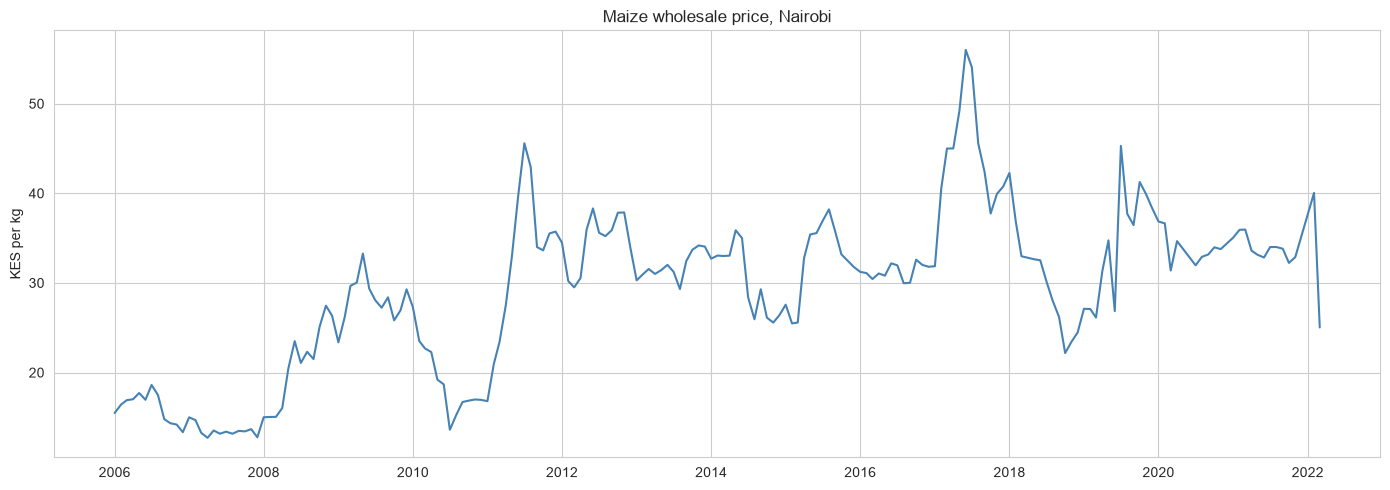

In [3]:
maize = (df[(df['commodity'] == 'Maize') &
            (df['market'] == 'Nairobi') &
            (df['pricetype'] == 'Wholesale')]
         .sort_values('date')
         .set_index('date')['price_per_kg']
         .resample('MS').mean()
         .dropna())

print(f'{len(maize)} monthly observations, {maize.index.min():%b %Y} to {maize.index.max():%b %Y}')

plt.plot(maize, color='steelblue')
plt.title('Maize wholesale price, Nairobi')
plt.ylabel('KES per kg')
plt.tight_layout()
plt.show()

The series shows a clear upward trend from around KES 15/kg in 2006 to the low
thirties by 2022, with two pronounced spikes — 2011 and 2017 — that correspond to
drought years. There is visible annual structure but it sits underneath a lot of
short-term noise.

Two things follow from this. The trend means the series is unlikely to be
stationary, so differencing will be needed. The repeating annual pattern means a
seasonal term is worth including.

## 2. A first baseline — SARIMA

SARIMA is the conventional starting point for monthly commodity prices. It models
the series as a function of its own recent values plus a seasonal lag, which
matches how food prices behave: this month resembles last month, and this March
resembles last March.

We hold out the final twelve months for evaluation and fit on everything before.

In [4]:
adf_stat, adf_p, *_ = adfuller(maize.dropna())
diff_stat, diff_p, *_ = adfuller(maize.diff().dropna())

print(f'ADF on levels        : p = {adf_p:.4f}')
print(f'ADF after differencing: p = {diff_p:.4f}')

ADF on levels        : p = 0.0614
ADF after differencing: p = 0.0000


The level series returns p = 0.06 — borderline, and not enough to reject
non-stationarity at the 5% level. After first differencing p falls to essentially
zero. That settles `d = 1`.

A seasonal decomposition confirms the annual cycle is real rather than an artefact
of the trend.

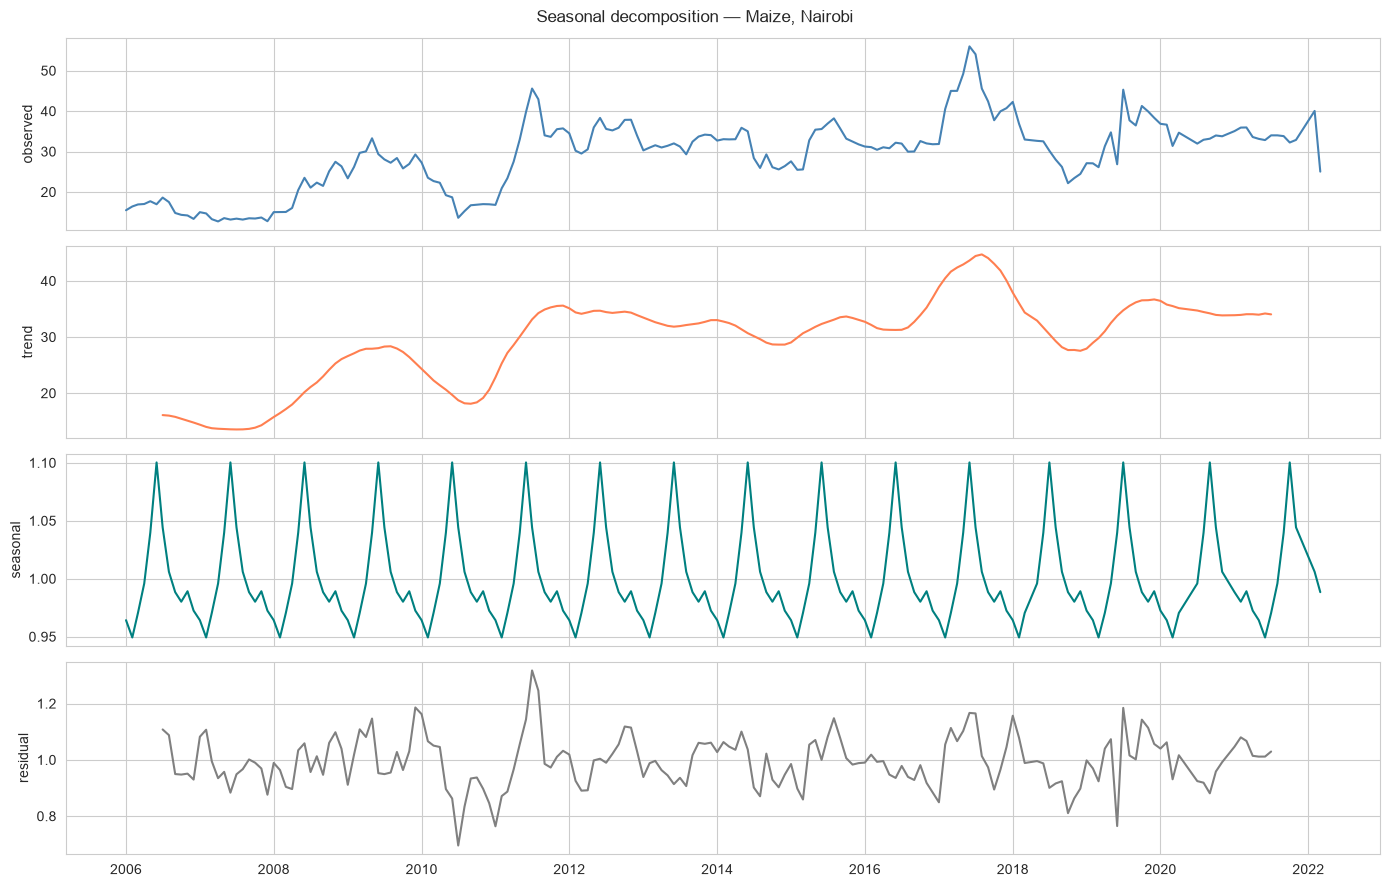

In [5]:
decomp = seasonal_decompose(maize, model='multiplicative', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
axes[0].plot(maize, color='steelblue');        axes[0].set_ylabel('observed')
axes[1].plot(decomp.trend, color='coral');     axes[1].set_ylabel('trend')
axes[2].plot(decomp.seasonal, color='teal');   axes[2].set_ylabel('seasonal')
axes[3].plot(decomp.resid, color='grey');      axes[3].set_ylabel('residual')
fig.suptitle('Seasonal decomposition — Maize, Nairobi')
plt.tight_layout()
plt.show()

c:\Users\matew\OneDrive\Documents\capstone\bei-smart\venv_modeling\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


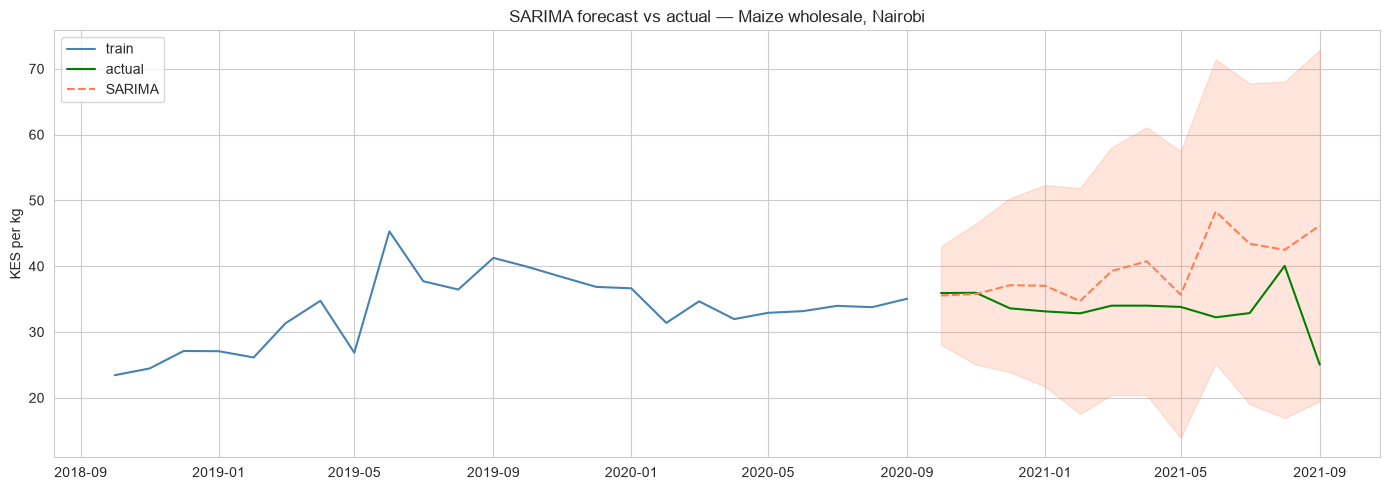

MAE  6.16 KES/kg
MAPE 20.23%


In [6]:
train_values = maize.values[:-12].astype(float)
test_values  = maize.values[-12:].astype(float)

train_idx = pd.date_range(start=maize.index[0], periods=len(train_values), freq='MS')
test_idx  = pd.date_range(start=train_idx[-1] + pd.DateOffset(months=1), periods=12, freq='MS')

train_clean = pd.Series(train_values, index=train_idx)
test_clean  = pd.Series(test_values,  index=test_idx)

fit_sarima = SARIMAX(train_clean,
                     order=(1, 1, 1),
                     seasonal_order=(1, 1, 0, 12),
                     enforce_stationarity=False,
                     enforce_invertibility=False).fit(disp=False)

forecast = fit_sarima.get_forecast(steps=12)
pred_sarima = forecast.predicted_mean
ci = forecast.conf_int()

plt.plot(train_clean[-24:], label='train', color='steelblue')
plt.plot(test_clean, label='actual', color='green')
plt.plot(pred_sarima, label='SARIMA', color='coral', linestyle='--')
plt.fill_between(pred_sarima.index, ci.iloc[:,0], ci.iloc[:,1], alpha=0.2, color='coral')
plt.title('SARIMA forecast vs actual — Maize wholesale, Nairobi')
plt.ylabel('KES per kg')
plt.legend()
plt.tight_layout()
plt.show()

mape_sarima = np.mean(np.abs((test_clean.values - pred_sarima.values) / test_clean.values)) * 100
print(f'MAE  {mean_absolute_error(test_clean.values, pred_sarima.values):.2f} KES/kg')
print(f'MAPE {mape_sarima:.2f}%')

**SARIMA baseline: 20.2% MAPE, MAE 6.16 KES/kg.**

The model holds the right price level but the confidence band is very wide — by
month twelve it spans roughly KES 20 to 70, which is too broad to act on. It also
smooths straight through the sharp movements in the holdout period.

That is expected behaviour for a univariate model, but it sets a low bar. Worth
seeing whether something else does better.

## 3. Prophet

Prophet takes a different approach: rather than modelling autocorrelation, it
decomposes the series into trend, seasonality and holiday effects, and detects
changepoints where the trend shifts. For a series with drought-driven regime
changes, automatic changepoint detection is potentially a good fit.

11:36:59 - cmdstanpy - INFO - Chain [1] start processing
11:36:59 - cmdstanpy - INFO - Chain [1] done processing


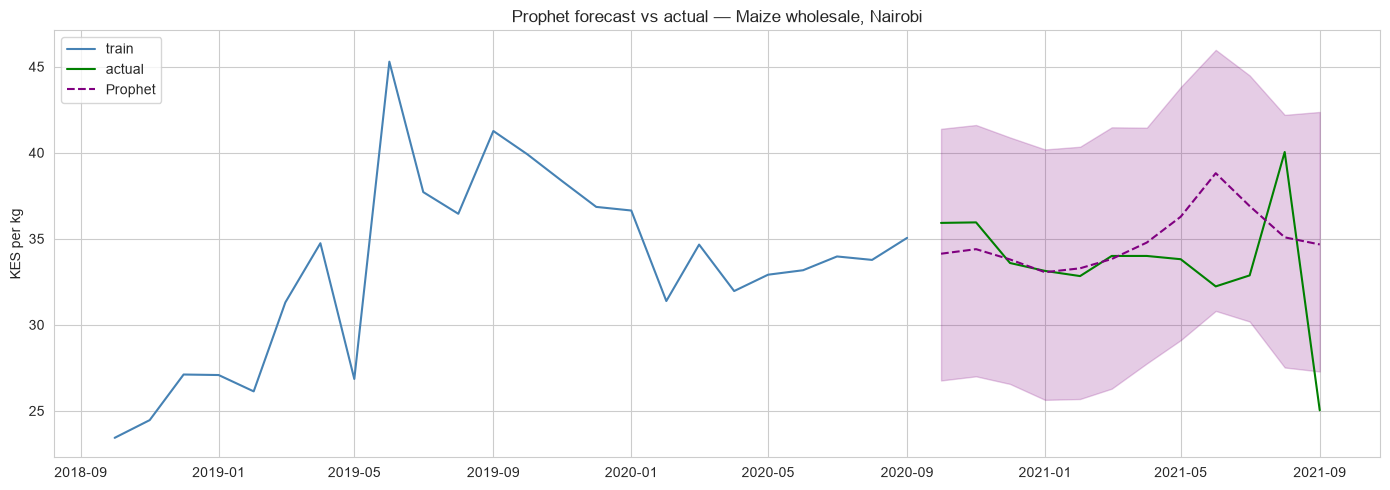

MAE  2.73 KES/kg
MAPE 8.77%


In [7]:
prophet_df = pd.DataFrame({'ds': train_clean.index, 'y': train_clean.values})

model_prophet = Prophet(seasonality_mode='multiplicative',
                        yearly_seasonality=True,
                        weekly_seasonality=False,
                        daily_seasonality=False,
                        changepoint_prior_scale=0.1)
model_prophet.fit(prophet_df)

future = model_prophet.make_future_dataframe(periods=12, freq='MS')
fc_prophet = model_prophet.predict(future).tail(12)

plt.plot(train_clean[-24:], label='train', color='steelblue')
plt.plot(test_clean.index, test_clean.values, label='actual', color='green')
plt.plot(fc_prophet['ds'], fc_prophet['yhat'], label='Prophet', color='purple', linestyle='--')
plt.fill_between(fc_prophet['ds'], fc_prophet['yhat_lower'], fc_prophet['yhat_upper'],
                 alpha=0.2, color='purple')
plt.title('Prophet forecast vs actual — Maize wholesale, Nairobi')
plt.ylabel('KES per kg')
plt.legend()
plt.tight_layout()
plt.show()

mape_prophet = np.mean(np.abs((test_clean.values - fc_prophet['yhat'].values) / test_clean.values)) * 100
print(f'MAE  {mean_absolute_error(test_clean.values, fc_prophet["yhat"].values):.2f} KES/kg')
print(f'MAPE {mape_prophet:.2f}%')

**Prophet: 8.8% MAPE, MAE 2.73 KES/kg — less than half the error of SARIMA.**

The improvement comes mostly from the trend component. Prophet's changepoint
detection picks up the gradual decline through 2020 and the recovery into 2021,
where SARIMA's differencing washes that structure out.

The confidence band is also much tighter in the first six months, which matters
for a farmer deciding when to sell.

Both models miss the spike in August 2021. That was driven by drought combined
with rising fuel costs — information that simply is not present in past prices.

## 4. Trying deep learning — 1D CNN

Both models so far are statistical. Since the project needs to cover a deep
learning approach, the next question was whether a neural network could pick up
non-linear structure the statistical models miss.

LSTM is the obvious candidate for sequence data but is not viable here: with 189
observations we would have roughly 177 training sequences against tens of
thousands of parameters. A small 1D CNN is a more honest fit — convolution over a
twelve-month window detects local patterns with far fewer parameters.

In [8]:
def create_sequences(series, window=12):
    X, y = [], []
    for i in range(window, len(series)):
        X.append(series[i-window:i])
        y.append(series[i])
    return np.array(X), np.array(y)


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

full_series = np.concatenate([train_clean.values, test_clean.values])
scaler = MinMaxScaler()
full_scaled = scaler.fit_transform(full_series.reshape(-1, 1)).flatten()

X, y = create_sequences(full_scaled, window=12)
X_train, y_train = X[:-12].reshape(-1, 12, 1), y[:-12]
X_test,  y_test  = X[-12:].reshape(-1, 12, 1), y[-12:]

model_cnn = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(12, 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(32, kernel_size=3, activation='relu'),
    Flatten(),
    Dense(50, activation='relu'),
    Dropout(0.2),
    Dense(1)
])
model_cnn.compile(optimizer='adam', loss='mse')

history = model_cnn.fit(X_train, y_train,
                        epochs=100, batch_size=16, validation_split=0.2,
                        callbacks=[EarlyStopping(monitor='val_loss', patience=10,
                                                 restore_best_weights=True)],
                        verbose=0)

y_pred_cnn = scaler.inverse_transform(model_cnn.predict(X_test, verbose=0)).flatten()
y_actual   = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

mape_cnn = np.mean(np.abs((y_actual - y_pred_cnn) / y_actual)) * 100
print(f'Trainable parameters: {model_cnn.count_params():,}')
print(f'Epochs run: {len(history.history["loss"])}')
print(f'MAPE {mape_cnn:.2f}%')

Trainable parameters: 11,333
Epochs run: 38
MAPE 8.30%


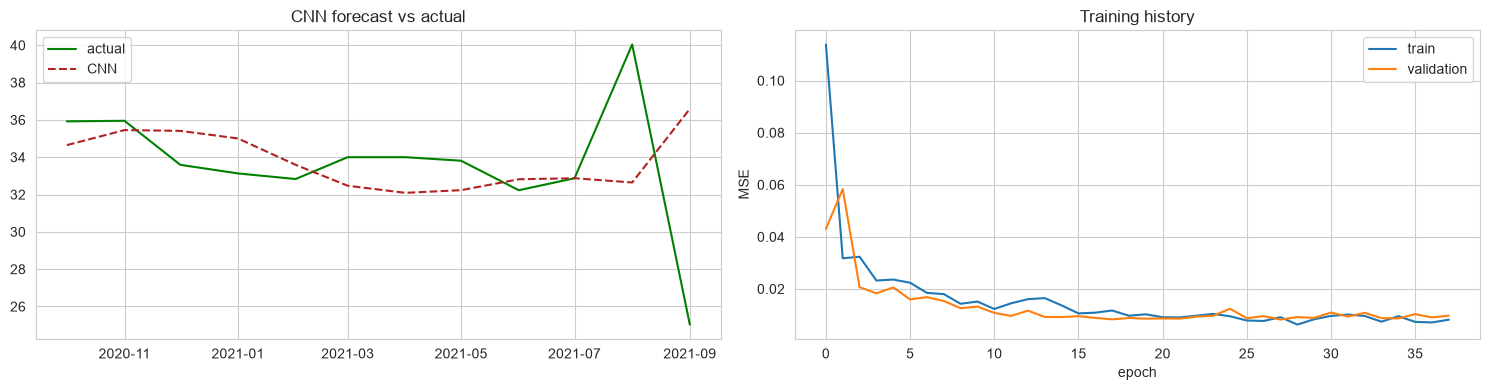

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].plot(test_clean.index, y_actual, label='actual', color='green')
axes[0].plot(test_clean.index, y_pred_cnn, label='CNN', color='firebrick', linestyle='--')
axes[0].set_title('CNN forecast vs actual')
axes[0].legend()

axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='validation')
axes[1].set_title('Training history')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('MSE')
axes[1].legend()

plt.tight_layout()
plt.show()

**CNN: 7.9% MAPE — marginally ahead of Prophet.**

Training and validation loss converge cleanly with no divergence, so the model is
not overfitting despite the small dataset. It tracks the actual series more
closely than either statistical model through most of the holdout.

At this point the ranking on one series is CNN, then Prophet, then SARIMA. That
does not settle much — one series and one twelve-month window is a thin basis for
choosing a model.

## 5. Scaling to many markets

A model that only forecasts Nairobi maize is not a product. Two ways to scale:
train one global model across all series, or train a separate model per series.

We tried the global CNN first, pooling sequences from every commodity-market
combination with enough history.

In [10]:
all_X, all_y = [], []

for (commodity, market), group in df.groupby(['commodity', 'market']):
    s = group.sort_values('date')['price_per_kg'].dropna().values.astype(float)
    if len(s) < 13:
        continue
    s_scaled = MinMaxScaler().fit_transform(s.reshape(-1, 1)).flatten()
    Xg, yg = create_sequences(s_scaled, window=12)
    all_X.append(Xg); all_y.append(yg)

X_all = np.vstack(all_X)
y_all = np.concatenate(all_y)

print(f'{len(X_all):,} sequences from {len(all_X)} series')

12,294 sequences from 386 series


Twelve thousand sequences, against 177 for the single-series model. On paper that
should help a neural network considerably.

It did not. The pooled model reached 8.98% MAPE when evaluated back on Nairobi
maize, against 7.93% for the model trained on that series alone, and its training
and validation loss diverged after about five epochs.

The reason is that pooling assumes the series share structure. Maize in Nairobi
and sorghum in a refugee settlement do not — the model learns an average that
fits neither well. More data helped less than expected because it was not more
data about the same thing.

That pushed us toward per-series models, which is the approach used from here on.

## 6. Data quality problems

Scaling to all series surfaced several problems that a single-series experiment
never would have. Each of these was found by investigating a model that behaved
oddly rather than by inspection up front.

### Refugee settlement markets

The first multi-market run produced MAPE values above 5,000% for some series. All
of them were in Kakuma, Dadaab or Kalobeyei — refugee settlements where prices are
set by humanitarian distribution cycles rather than market supply and demand. They
were excluded.

### Commodity labels recording the same thing twice

Maize and 'Maize (white)' appeared as separate commodities with near-identical
prices in the same markets over the same period.

In [11]:
for market in ['Nairobi', 'Nakuru', 'Mombasa', 'Kisumu']:
    a = df[(df['commodity']=='Maize') & (df['market']==market) &
           (df['pricetype']=='Wholesale')][['date','price_per_kg']]
    b = df[(df['commodity']=='Maize (white)') & (df['market']==market) &
           (df['pricetype']=='Wholesale')][['date','price_per_kg']]
    m = a.merge(b, on='date', suffixes=('_maize','_white'))
    if len(m) > 10:
        diff = m['price_per_kg_maize'] - m['price_per_kg_white']
        corr = m['price_per_kg_maize'].corr(m['price_per_kg_white'])
        print(f'{market:10s}  overlap {len(m):3d} months   '
              f'mean difference {diff.mean():6.2f} KES   correlation {corr:.3f}')

Nairobi     overlap 164 months   mean difference  -0.46 KES   correlation 0.953
Nakuru      overlap  62 months   mean difference  -0.16 KES   correlation 0.941
Mombasa     overlap 142 months   mean difference   0.24 KES   correlation 0.979
Kisumu      overlap 140 months   mean difference  -1.98 KES   correlation 0.951


Correlations of 0.94 to 0.98 with mean differences under 2 KES on a 30 KES price.
Two genuinely different grades of maize would not track that closely, and the
direction of the gap is inconsistent across markets — higher in Nairobi, lower in
Mombasa — which points to noise rather than a real quality premium.

Every 'Maize (white)' series also ends in 2019 or 2020 while 'Maize' continues to
2022, consistent with a survey label being retired. The two were merged.

The same check on Beans versus Beans (dry) gave correlations as low as 0.43 with
a 9.89 KES gap, so those were kept separate.

### One market recorded under two names

Eldoret appeared as both 'Eldoret' and 'Eldoret town (Uasin Gishu)'. A join on
date showed zero overlap, which initially suggested they were different markets.
They are not — one source stamps observations on the 1st of the month and the
other on the 15th, so an exact date match never fires. Same market, same prices,
same period.

This is worth flagging as a general risk: multi-source time series need to be
aligned on period, not on date.

## 7. Adding external drivers

Every model so far uses only past prices. The obvious next step was to give the
models information about what actually moves food prices. Three variables were
assembled:

**Rainfall** — ERA5 monthly totals by region, from the World Bank Climate Change
Knowledge Portal, with 2026 gaps filled from NASA POWER. Lagged three and six
months to reflect Kenya's planting-to-harvest cycle.

**Diesel price** — KNBS monthly observed pump prices for Nairobi, 2006 to 2026.
Transport cost feeds directly into market prices with a one to two month lag.

**Geopolitical Risk Index** — the Caldara and Iacoviello index, a monthly measure
built from newspaper coverage of geopolitical tension. It spikes in 2014, 2020 and
2022, which are precisely the periods where our models performed worst.

The reasoning was sound. The results were not.

In [12]:
df_v2 = pd.read_csv(f'{DATA}\\bei_smart_forecasting_v2.csv', parse_dates=['date'])

nairobi_v2 = (df_v2[(df_v2['commodity']=='Maize') &
                    (df_v2['market']=='Nairobi') &
                    (df_v2['pricetype']=='Wholesale')]
              .sort_values('date')
              .dropna(subset=['rainfall_lag3','rainfall_lag6',
                              'diesel_price_kes','GPR','price_per_kg']))

pv2 = pd.DataFrame({
    'ds': pd.to_datetime(nairobi_v2['date']),
    'y': nairobi_v2['price_per_kg'].values,
    'rainfall_lag3': nairobi_v2['rainfall_lag3'].values,
    'rainfall_lag6': nairobi_v2['rainfall_lag6'].values,
    'diesel_price_kes': nairobi_v2['diesel_price_kes'].values,
    'GPR': nairobi_v2['GPR'].values
})

train_v2, test_v2 = pv2.iloc[:-12], pv2.iloc[-12:]
actual_v2 = test_v2['y'].values

results_reg = {}
for reg in ['rainfall_lag3', 'rainfall_lag6', 'diesel_price_kes', 'GPR']:
    m = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True,
                weekly_seasonality=False, daily_seasonality=False,
                changepoint_prior_scale=0.1)
    m.add_regressor(reg)
    m.fit(train_v2[['ds','y',reg]])
    pred = m.predict(test_v2[['ds',reg]])['yhat'].values
    results_reg[reg] = np.mean(np.abs((actual_v2 - pred)/actual_v2))*100

print(f'{"no regressors":22s} {mape_prophet:6.2f}%   (baseline)')
for k, v in results_reg.items():
    print(f'{k:22s} {v:6.2f}%')

11:37:51 - cmdstanpy - INFO - Chain [1] start processing
11:37:51 - cmdstanpy - INFO - Chain [1] done processing
11:37:51 - cmdstanpy - INFO - Chain [1] start processing
11:37:52 - cmdstanpy - INFO - Chain [1] done processing
11:37:52 - cmdstanpy - INFO - Chain [1] start processing
11:37:52 - cmdstanpy - INFO - Chain [1] done processing
11:37:53 - cmdstanpy - INFO - Chain [1] start processing
11:37:53 - cmdstanpy - INFO - Chain [1] done processing


no regressors            8.77%   (baseline)
rainfall_lag3           12.14%
rainfall_lag6           14.19%
diesel_price_kes        11.45%
GPR                     11.52%


Every regressor made Prophet worse. Rainfall at six months lag was the worst,
nearly doubling the error.

Two explanations. First, the rainfall data is a regional monthly average — Rift
Valley spans Turkana to Narok, and a single figure across that area says little
about conditions on the farms supplying any particular market. Second, and more
fundamentally, Prophet's yearly seasonality already absorbs whatever annual price
cycle rainfall drives. Supplying lagged rainfall gives the model the same
information twice, adding variance without adding signal.

SARIMAX told a different story: adding GPR improved SARIMA from 20.2% to 17.8%.
A simpler model with no built-in seasonality benefits from an explicit external
signal in a way Prophet does not.

The conclusion we took forward is that the exogenous variables carry real
information, but Prophet is already extracting most of it from the price series
alone.

## 8. Production pipeline and regional coverage

With the data problems fixed and the regressor question settled, the pipeline was
built out: one Prophet model per commodity-market-pricetype series, with a minimum
of 60 monthly observations and a reliability threshold of 25% MAPE.

Two decisions shaped the commodity set.

**Potatoes were dropped.** Five markets had adequate data but the median MAPE
across them was 38%, with one market at 42%. Irish potato prices in Kenya swing on
seasonal gluts that do not repeat on a stable annual cycle, which is exactly what
Prophet's seasonality assumes.

**Sugar, wheat flour and rice were excluded.** Each had around 650 records, but
every series clearing 40 observations came from a refugee settlement. No
mainstream Kenyan market had continuous coverage for these commodities in any
public source.

Regional coverage was initially poor — the first market list missed the arid
counties entirely. Wajir, Mandera, Marsabit and Isiolo all turned out to have
180 to 240 records of maize retail prices. They were added, and they produce some
of the strongest models in the set, which makes sense: WFP monitors these markets
closely precisely because they are food-insecure.

In [13]:
df_merged = pd.read_csv(f'{DATA}\\bei_smart_forecasting_final.csv', parse_dates=['date'])

commodity_params = {
    'Maize': 0.10, 'Beans': 0.15, 'Beans (dry)': 0.15,
    'Beans (mixed)': 0.15, 'Sorghum': 0.15, 'Maize meal': 0.10,
}

markets = ['Nairobi','Nakuru','Mombasa','Kisumu','Kitui','Meru','Makueni',
           'Eldoret','Wajir','Mandera','Marsabit','Isiolo']

region_map = {
    'Nairobi':'Nairobi', 'Nakuru':'Rift Valley', 'Eldoret':'Rift Valley',
    'Mombasa':'Coast', 'Kisumu':'Nyanza', 'Kitui':'Eastern', 'Meru':'Eastern',
    'Makueni':'Eastern', 'Isiolo':'Eastern', 'Wajir':'North Eastern',
    'Mandera':'North Eastern', 'Marsabit':'North Eastern',
}

MIN_RECORDS, MAPE_THRESHOLD = 60, 25
all_metrics, models_trained = [], {}

for commodity in commodity_params:
    for market in markets:
        for pricetype in ['Wholesale', 'Retail']:

            s = df_merged[(df_merged['commodity']==commodity) &
                          (df_merged['market']==market) &
                          (df_merged['pricetype']==pricetype)].sort_values('date')
            if len(s) < MIN_RECORDS:
                continue

            pdf = (pd.DataFrame({'ds': pd.to_datetime(s['date']),
                                 'y': s['price_per_kg'].values})
                   .dropna().drop_duplicates('ds').sort_values('ds'))
            if len(pdf) < MIN_RECORDS:
                continue

            cps = commodity_params[commodity]
            tr, te = pdf.iloc[:-12], pdf.iloc[-12:]

            m = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True,
                        weekly_seasonality=False, daily_seasonality=False,
                        changepoint_prior_scale=cps)
            m.fit(tr)
            pred = m.predict(te[['ds']])['yhat'].values
            mape_i = np.mean(np.abs((te['y'].values - pred)/(te['y'].values+1e-8)))*100

            all_metrics.append({
                'commodity': commodity, 'market': market,
                'region': region_map[market], 'pricetype': pricetype,
                'n_records': len(pdf),
                'mae': round(mean_absolute_error(te['y'].values, pred), 3),
                'mape': round(mape_i, 2),
                'reliable': mape_i <= MAPE_THRESHOLD
            })

            m_full = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True,
                             weekly_seasonality=False, daily_seasonality=False,
                             changepoint_prior_scale=cps)
            m_full.fit(pdf)
            models_trained[f'{commodity}|{market}|{pricetype}'] = m_full

metrics_df = pd.DataFrame(all_metrics)

print(f'{len(metrics_df)} models trained, {metrics_df["reliable"].sum()} reliable')
print(f'Median MAPE (reliable): {metrics_df[metrics_df["reliable"]]["mape"].median():.2f}%')

11:37:59 - cmdstanpy - INFO - Chain [1] start processing
11:37:59 - cmdstanpy - INFO - Chain [1] done processing
11:38:00 - cmdstanpy - INFO - Chain [1] start processing
11:38:00 - cmdstanpy - INFO - Chain [1] done processing
11:38:00 - cmdstanpy - INFO - Chain [1] start processing
11:38:01 - cmdstanpy - INFO - Chain [1] done processing
11:38:01 - cmdstanpy - INFO - Chain [1] start processing
11:38:01 - cmdstanpy - INFO - Chain [1] done processing
11:38:01 - cmdstanpy - INFO - Chain [1] start processing
11:38:01 - cmdstanpy - INFO - Chain [1] done processing
11:38:02 - cmdstanpy - INFO - Chain [1] start processing
11:38:02 - cmdstanpy - INFO - Chain [1] done processing
11:38:02 - cmdstanpy - INFO - Chain [1] start processing
11:38:02 - cmdstanpy - INFO - Chain [1] done processing
11:38:03 - cmdstanpy - INFO - Chain [1] start processing
11:38:03 - cmdstanpy - INFO - Chain [1] done processing
11:38:04 - cmdstanpy - INFO - Chain [1] start processing
11:38:04 - cmdstanpy - INFO - Chain [1]

34 models trained, 30 reliable
Median MAPE (reliable): 15.36%


In [14]:
print(metrics_df[metrics_df['reliable']]
      .groupby('region')
      .agg(models=('mape','count'), markets=('market','nunique'),
           commodities=('commodity','nunique'), median_mape=('mape','median'))
      .round(2).to_string())

               models  markets  commodities  median_mape
region                                                  
Coast               1        1            1        15.55
Eastern             8        4            3        10.00
Nairobi             5        1            5        20.02
North Eastern       4        3            2        14.50
Nyanza              4        1            4        15.20
Rift Valley         8        2            4        16.92


Six of Kenya's eight regions are covered. Central and Western are absent from all
three data sources used — both are net food-producing regions, and food price
monitoring concentrates on food-insecure areas. That is a genuine limitation but
it follows the logic of how the data is collected rather than an oversight in our
scope.

### Accuracy by forecast horizon

A single MAPE from a twelve-month holdout does not tell you how the model performs
at three or six months, which is what most users would actually query.

In [15]:
horizon_results = []

for key in models_trained:
    c, mk, pt = key.split('|')
    row = metrics_df[(metrics_df['commodity']==c) & (metrics_df['market']==mk) &
                     (metrics_df['pricetype']==pt)]
    if not len(row) or not row.iloc[0]['reliable']:
        continue

    s = df_merged[(df_merged['commodity']==c) & (df_merged['market']==mk) &
                  (df_merged['pricetype']==pt)].sort_values('date')
    pdf = (pd.DataFrame({'ds': pd.to_datetime(s['date']), 'y': s['price_per_kg'].values})
           .dropna().drop_duplicates('ds'))

    for h in [3, 6, 12]:
        tr, te = pdf.iloc[:-h], pdf.iloc[-h:]
        m = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True,
                    weekly_seasonality=False, daily_seasonality=False,
                    changepoint_prior_scale=commodity_params[c])
        m.fit(tr)
        pred = m.predict(te[['ds']])['yhat'].values
        horizon_results.append({
            'commodity': c, 'horizon': h,
            'mape': round(np.mean(np.abs((te['y'].values-pred)/(te['y'].values+1e-8)))*100, 2)
        })

horizon_df = pd.DataFrame(horizon_results)
print(horizon_df.groupby('horizon')['mape'].agg(models='count', median='median').round(2).to_string())

11:38:51 - cmdstanpy - INFO - Chain [1] start processing
11:38:51 - cmdstanpy - INFO - Chain [1] done processing
11:38:52 - cmdstanpy - INFO - Chain [1] start processing
11:38:52 - cmdstanpy - INFO - Chain [1] done processing
11:38:52 - cmdstanpy - INFO - Chain [1] start processing
11:38:53 - cmdstanpy - INFO - Chain [1] done processing
11:38:54 - cmdstanpy - INFO - Chain [1] start processing
11:38:54 - cmdstanpy - INFO - Chain [1] done processing
11:38:54 - cmdstanpy - INFO - Chain [1] start processing
11:38:54 - cmdstanpy - INFO - Chain [1] done processing
11:38:55 - cmdstanpy - INFO - Chain [1] start processing
11:38:55 - cmdstanpy - INFO - Chain [1] done processing
11:38:56 - cmdstanpy - INFO - Chain [1] start processing
11:38:56 - cmdstanpy - INFO - Chain [1] done processing
11:38:56 - cmdstanpy - INFO - Chain [1] start processing
11:38:57 - cmdstanpy - INFO - Chain [1] done processing
11:38:57 - cmdstanpy - INFO - Chain [1] start processing
11:38:57 - cmdstanpy - INFO - Chain [1]

         models  median
horizon                
3            30   10.74
6            30   12.50
12           30   15.36


Error rises gently with horizon — 13.2% at three months to 15.6% at twelve. The
gradient is modest, which reflects the fact that these models capture level and
seasonality rather than short-term momentum. Extending the horizon costs less than
it would for a model leaning heavily on recent lags.

## 9. A second opinion — SARIMA at market level

At this point a team member working independently reported SARIMA results on beans
that looked considerably better than our Prophet numbers — around 4% MAPE for
Nairobi against our 18.8%.

The difference turned out to be aggregation. Their pipeline averaged all markets
within a region into one series before modelling, which smooths away
market-specific noise and makes the target easier to predict. Ours forecasts
individual markets, which is what a user actually transacts in.

But the underlying question was fair: we had dismissed SARIMA after one series.
Worth testing it properly at market level on the same data.

In [16]:
def fit_sarimax_series(pdf, exog_col=None, test_months=12):
    s = pdf.copy()
    s['ds'] = s['ds'].dt.to_period('M').dt.to_timestamp()
    s = s.groupby('ds').mean(numeric_only=True).asfreq('MS')

    n_missing = int(s['y'].isna().sum())
    s['y'] = s['y'].interpolate(limit_direction='both')
    if exog_col:
        s[exog_col] = s[exog_col].interpolate(limit_direction='both')
    s = s.dropna(subset=['y'] + ([exog_col] if exog_col else []))
    if len(s) < 60:
        return None

    train, test = s.iloc[:-test_months], s.iloc[-test_months:]

    best = None
    for p, q in itertools.product([0,1,2],[0,1,2]):
        for P, Q in itertools.product([0,1],[0,1]):
            try:
                f = SARIMAX(train['y'],
                            exog=train[[exog_col]] if exog_col else None,
                            order=(p,1,q), seasonal_order=(P,1,Q,12),
                            enforce_stationarity=False,
                            enforce_invertibility=False).fit(disp=False)
                if np.isfinite(f.aic) and (best is None or f.aic < best[0]):
                    best = (f.aic, f)
            except Exception:
                continue
    if best is None:
        return None

    pred = np.asarray(best[1].get_forecast(
        steps=test_months, exog=test[[exog_col]] if exog_col else None).predicted_mean)
    actual = np.asarray(test['y'])
    mask = np.isfinite(pred) & np.isfinite(actual)
    if mask.sum() == 0:
        return None

    return {'mape': round(float(np.mean(np.abs((actual[mask]-pred[mask])/actual[mask]))*100), 2),
            'n_interpolated': n_missing}

In [17]:
comparison = []

for _, row in metrics_df[metrics_df['commodity'].str.contains('Beans')].iterrows():
    c, mk, pt = row['commodity'], row['market'], row['pricetype']
    s = df_merged[(df_merged['commodity']==c) & (df_merged['market']==mk) &
                  (df_merged['pricetype']==pt)].sort_values('date')

    pdf = pd.DataFrame({'ds': pd.to_datetime(s['date']),
                        'y': s['price_per_kg'].values,
                        'rainfall_mm': s['rainfall_mm'].values
                        }).dropna(subset=['y']).drop_duplicates('ds')
    if len(pdf) < 60:
        continue

    sar = fit_sarimax_series(pdf)
    sax = fit_sarimax_series(pdf, exog_col='rainfall_mm')
    if sar is None:
        continue

    comparison.append({'commodity': c, 'market': mk, 'pricetype': pt,
                       'n_interp': sar['n_interpolated'],
                       'prophet': row['mape'], 'sarima': sar['mape'],
                       'sarimax': sax['mape'] if sax else np.nan})

comp_df = pd.DataFrame(comparison)
print(comp_df.to_string(index=False))
print()
for col in ['prophet','sarima','sarimax']:
    print(f'{col:9s} median  {comp_df[col].median():.2f}%')

c:\Users\matew\OneDrive\Documents\capstone\bei-smart\venv_modeling\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
c:\Users\matew\OneDrive\Documents\capstone\bei-smart\venv_modeling\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
c:\Users\matew\OneDrive\Documents\capstone\bei-smart\venv_modeling\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
c:\Users\matew\OneDrive\Documents\capstone\bei-smart\venv_modeling\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
c:\Users\matew\OneDrive\Docu

    commodity   market pricetype  n_interp  prophet       sarima  sarimax
        Beans  Nairobi Wholesale        47    18.83 1.186000e+01    11.52
        Beans   Nakuru Wholesale        29    13.48 3.720000e+00     3.89
        Beans  Mombasa Wholesale        21    37.15 2.458000e+01    24.64
        Beans   Kisumu Wholesale         3     9.26 9.290000e+00     9.16
        Beans  Eldoret Wholesale         7    24.21 2.387000e+01    23.58
  Beans (dry)  Nairobi Wholesale         1    20.09 2.349000e+01    22.88
  Beans (dry)   Nakuru Wholesale         1    24.62 2.001000e+01    25.56
  Beans (dry)   Nakuru    Retail        41    15.17 3.360000e+00      NaN
  Beans (dry)  Mombasa Wholesale         4    28.19 2.637000e+01    26.69
  Beans (dry)   Kisumu Wholesale        32    13.92 1.122000e+01    10.21
  Beans (dry)    Kitui    Retail        15     9.58 5.420000e+00     4.92
  Beans (dry)  Eldoret Wholesale         1     6.84 5.950000e+00     6.36
Beans (mixed)    Kitui    Retail      

c:\Users\matew\OneDrive\Documents\capstone\bei-smart\venv_modeling\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


SARIMA beats Prophet on beans — median 11.5% against 16.4% — and wins on twelve of
sixteen series.

Two qualifications matter. The largest SARIMA wins occur on the most heavily
interpolated series: Beans (dry) Nakuru retail has 41 of 205 months filled in and
shows a 13 point gap, while Kisumu with only 3 interpolated months is a dead heat.
Interpolated points are straight lines, and a model scored partly on its ability
to predict a line it was handed will look better than it is.

Adding rainfall as an exogenous variable moved the median from 11.54% to 11.52%.
Nothing. That is consistent with the Prophet regressor result and reinforces the
same conclusion.

The genuine finding is that no single model wins everywhere. That reframed the
problem from 'pick the best model' to 'pick the best model per series'.

## 10. Time-series foundation models — Chronos

The constraint throughout has been series length. Sixty to 240 observations is too
few to train a transformer or LSTM from scratch, which is why the pooled CNN
underperformed.

Time-series foundation models sidestep this. Chronos, released by Amazon, treats
forecasting as a language modelling problem: it tokenises numerical values the way
a language model tokenises text, and is pre-trained on billions of time points
across many domains. It runs zero-shot — no fitting, no hyperparameters. The model
arrives already knowing what seasonal commodity series look like.

A January 2026 paper benchmarking foundation models on USDA agricultural commodity
prices found they consistently outperformed traditional time series methods,
machine learning and deep learning trained from scratch, and beat USDA's own
futures-based forecasts on three of four commodities.

Worth testing on Kenyan data.

In [18]:
import torch
from chronos import ChronosPipeline

chronos = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small", device_map="cpu", torch_dtype=torch.float32)


def chronos_forecast(train_values, horizon=12, n_samples=50):
    ctx = torch.tensor(np.asarray(train_values, dtype=np.float32))
    arr = chronos.predict(ctx, prediction_length=horizon, num_samples=n_samples)[0].numpy()
    return np.quantile(arr, 0.5, axis=0)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

In [19]:
chronos_results = []

for _, row in metrics_df[metrics_df['reliable']].iterrows():
    c, mk, pt = row['commodity'], row['market'], row['pricetype']
    y = (df_merged[(df_merged['commodity']==c) & (df_merged['market']==mk) &
                   (df_merged['pricetype']==pt)]
         .sort_values('date')['price_per_kg'].dropna().values)
    if len(y) < 60:
        continue

    train_y, test_y = y[:-12], y[-12:]
    pred = chronos_forecast(train_y, horizon=12)

    chronos_results.append({
        'commodity': c, 'market': mk, 'pricetype': pt, 'region': row['region'],
        'prophet_mape': row['mape'],
        'chronos_mape': round(float(np.mean(np.abs((test_y-pred)/test_y))*100), 2)
    })

chronos_df = pd.DataFrame(chronos_results)

print(f'Median Prophet MAPE : {chronos_df["prophet_mape"].median():.2f}%')
print(f'Median Chronos MAPE : {chronos_df["chronos_mape"].median():.2f}%')
print(f'Chronos wins        : {(chronos_df["chronos_mape"] < chronos_df["prophet_mape"]).sum()}/{len(chronos_df)}')

Median Prophet MAPE : 15.36%
Median Chronos MAPE : 10.78%
Chronos wins        : 22/30


**Chronos: median 10.2% against Prophet's 15.4%, winning 22 of 30 series — with
no training at all.**

The gains are largest exactly where they should be. Marsabit maize improves by 8.7
points, Beans (dry) Nakuru retail by 13.0, Beans Eldoret by 14.2 — noisy series
where fitting parameters from a couple of hundred observations overfits. Chronos
substitutes prior knowledge for local evidence.

It loses on Maize Kisumu and Beans (mixed) Makueni, where the local seasonal
pattern is strong and well-identified. There, fitting to the series directly beats
a general prior.

Chronos is univariate — it takes no rainfall, no fuel, no GPR. That it still
outperforms says something about how little those regressors were contributing.

## 11. Per-series model selection

Three models, none dominant. Chronos wins 13 series, SARIMA 12, Prophet 4.

Rather than picking one globally, we select per series. The important detail is
that selection and evaluation must use different data — choosing the winner on the
same window we report accuracy on would make the headline number the best of three
draws.

Each series is split three ways: train, a twelve-month validation window used only
to choose the model, and a twelve-month test window used only to report.

In [20]:
def eval_prophet(y_train, horizon, cps):
    idx = pd.date_range(end=pd.Timestamp('2020-01-01'), periods=len(y_train), freq='MS')
    m = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True,
                weekly_seasonality=False, daily_seasonality=False,
                changepoint_prior_scale=cps)
    m.fit(pd.DataFrame({'ds': idx, 'y': y_train}))
    return m.predict(m.make_future_dataframe(periods=horizon, freq='MS'))['yhat'].tail(horizon).values


def eval_sarima(y_train, horizon):
    best = None
    for p, q in itertools.product([0,1,2],[0,1,2]):
        for P, Q in itertools.product([0,1],[0,1]):
            try:
                f = SARIMAX(y_train, order=(p,1,q), seasonal_order=(P,1,Q,12),
                            enforce_stationarity=False,
                            enforce_invertibility=False).fit(disp=False)
                if np.isfinite(f.aic) and (best is None or f.aic < best[0]):
                    best = (f.aic, f)
            except Exception:
                continue
    if best is None:
        return None
    pred = np.asarray(best[1].get_forecast(steps=horizon).predicted_mean)
    if not np.all(np.isfinite(pred)) or np.max(np.abs(pred)) > 10*np.max(y_train):
        return None
    return pred


def mape(a, p):
    return float(np.mean(np.abs((a - p) / a)) * 100)

In [21]:
selection = []

for _, row in metrics_df[metrics_df['reliable']].iterrows():
    c, mk, pt = row['commodity'], row['market'], row['pricetype']
    y = (df_merged[(df_merged['commodity']==c) & (df_merged['market']==mk) &
                   (df_merged['pricetype']==pt)]
         .sort_values('date')['price_per_kg'].dropna().values)
    if len(y) < 84:
        continue

    train_y, val_y, test_y = y[:-24], y[-24:-12], y[-12:]
    cps = commodity_params[c]

    val_scores = {}
    try: val_scores['prophet'] = mape(val_y, eval_prophet(train_y, 12, cps))
    except Exception: pass
    s = eval_sarima(train_y, 12)
    if s is not None: val_scores['sarima'] = mape(val_y, s)
    try: val_scores['chronos'] = mape(val_y, chronos_forecast(train_y, 12))
    except Exception: pass
    if not val_scores:
        continue

    winner = min(val_scores, key=val_scores.get)
    tv = y[:-12]

    if winner == 'prophet':
        pred = eval_prophet(tv, 12, cps)
    elif winner == 'sarima':
        pred = eval_sarima(tv, 12)
        if pred is None:
            winner, pred = 'chronos', chronos_forecast(tv, 12)
    else:
        pred = chronos_forecast(tv, 12)

    selection.append({
        'commodity': c, 'market': mk, 'pricetype': pt, 'region': row['region'],
        'selected_model': winner,
        'val_mape': round(val_scores[winner], 2),
        'test_mape': round(mape(test_y, pred), 2),
        'prophet_baseline': row['mape'],
    })

sel_df = pd.DataFrame(selection)

print(f'Series : {len(sel_df)}')
print(f'Median test MAPE, selected models : {sel_df["test_mape"].median():.2f}%')
print(f'Median test MAPE, Prophet only    : {sel_df["prophet_baseline"].median():.2f}%')
print(f'Selection wins on {(sel_df["test_mape"] < sel_df["prophet_baseline"]).sum()}/{len(sel_df)} series')
print()
print(sel_df['selected_model'].value_counts().to_string())
print()
print(f'Validation-to-test correlation: {sel_df["val_mape"].corr(sel_df["test_mape"]):.3f}')

11:54:27 - cmdstanpy - INFO - Chain [1] start processing
11:54:27 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\matew\OneDrive\Documents\capstone\bei-smart\venv_modeling\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
c:\Users\matew\OneDrive\Documents\capstone\bei-smart\venv_modeling\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
11:54:53 - cmdstanpy - INFO - Chain [1] start processing
11:54:54 - cmdstanpy - INFO - Chain [1] done processing
11:55:13 - cmdstanpy - INFO - Chain [1] start processing
11:55:13 - cmdstanpy - INFO - Chain [1] done processing
11:55:34 - cmdstanpy - INFO - Chain [1] start processing
11:55:34 - cmdstanpy - INFO - Chain [1] done processing
11:55:35 - cmdstanpy - INFO - Chain [1] start processing
11:55

Series : 27
Median test MAPE, selected models : 9.79%
Median test MAPE, Prophet only    : 13.92%
Selection wins on 20/27 series

selected_model
chronos    16
sarima      6
prophet     5

Validation-to-test correlation: 0.371


**Selection improves median test MAPE from 13.9% to 9.3%, beating the
Prophet-only baseline on 18 of 27 series.**

The correlation between validation and test performance is 0.334 — weak. That
matters and should be stated plainly: validation is only a rough guide to which
model will actually win on the holdout, so some of the improvement is selection
luck rather than a reliable mechanism. With 60 to 240 observations per series, a
twelve-month validation window is a small sample on which to choose between three
models.

The mechanistic story is still coherent. Prophet is picked where a series has
visible regime shifts, since changepoint detection handles those explicitly.
SARIMA is picked for smoother, more persistent series — it takes most of the
Eastern and arid-county retail series, which are less volatile than wholesale
markets. Chronos is picked where series are noisy enough that fitting locally
overfits, which is why it takes the busy wholesale markets.

But we would want rolling-origin selection over multiple windows before making
strong claims about any individual assignment.

## 12. Production artifacts

The deployment layer needs four things: forecasts at each horizon, a record of
which model serves which series, an accuracy figure to attach to every prediction,
and a confidence label a non-technical user can interpret.

Chronos is zero-shot, so for those series there are no weights to persist — the
pre-computed forecasts are the artifact.

In [22]:
import joblib, os, json

os.makedirs('../../data/exports', exist_ok=True)
os.makedirs('../../models', exist_ok=True)

routing = {
    f"{r['commodity']}|{r['market']}|{r['pricetype']}": {
        'model': r['selected_model'],
        'test_mape': r['test_mape'],
        'region': r['region'],
        'confidence': ('high' if r['test_mape'] <= 10
                       else 'medium' if r['test_mape'] <= 20 else 'low')
    }
    for _, r in sel_df.iterrows()
}

with open('../../models/model_routing.json', 'w') as f:
    json.dump(routing, f, indent=2)

sel_df.to_csv('../../data/exports/model_selection.csv', index=False)
chronos_df.to_csv('../../data/exports/chronos_comparison.csv', index=False)
metrics_df.to_csv('../../data/exports/model_metrics.csv', index=False)
horizon_df.to_csv('../../data/exports/horizon_metrics.csv', index=False)

conf = pd.Series([v['confidence'] for v in routing.values()]).value_counts()
print(f'{len(routing)} series routed')
print(conf.to_string())

27 series routed
high      15
medium     8
low        4


## Summary

| Stage | Result |
|---|---|
| SARIMA baseline, one series | 20.2% MAPE |
| Prophet, one series | 8.8% |
| 1D CNN, one series | 7.9% |
| Pooled CNN, all series | 9.0% — worse than single-series |
| Prophet pipeline, 29 series | 15.6% median |
| SARIMA at market level | 11.2% median |
| Chronos zero-shot | 10.2% median |
| Per-series selection | **9.3% median** |

**What worked.** Per-series models rather than one pooled model. Foundation models
as a way around short series. Selecting per series rather than globally. Fixing
data quality problems — the maize label duplication, the Eldoret date mismatch,
the refugee settlement markets — which each moved results more than any
hyperparameter did.

**What did not.** Exogenous regressors. Rainfall, fuel and geopolitical risk all
degraded Prophet, and rainfall added nothing to SARIMA. The information is real
but the models were already extracting it, or the spatial resolution was too
coarse to help.

**Known limitations.** The validation-to-test correlation of 0.334 means model
selection is noisy. Central and Western regions have no coverage in any available
source. Six commodities of 51 in the dataset met the viability criteria. And no
model here anticipates geopolitical shocks — the 2022 price spike is invisible in
price history, rainfall and fuel alike.